## Test Jaccobian Matrix of the trasformation using matrix notation and calculations

\begin{equation}
    \mathbb{J}_{X \varepsilon } \equiv \frac{\partial \widetilde{X}}{\partial \widetilde{\varepsilon}} \equiv 
    \begin{pmatrix} 
    \partial_ax & \partial_ex & \partial_ix & \partial_\Omega x & \partial_wx & \partial_Mx\\
    \partial_ay & \partial_ey & \partial_iy & \partial_\Omega y & \partial_wy & \partial_My \\
    \partial_az & \partial_ez & \partial_iz & \partial_\Omega z & \partial_wz & \partial_Mz \\
    \partial_av_x & \partial_ev_x & \partial_iv_x & \partial_\Omega v_x & \partial_wv_x & \partial_Mv_x \\
    \partial_av_y & \partial_ev_y & \partial_iv_y & \partial_\Omega v_y & \partial_wv_y & \partial_Mv_y \\
    \partial_av_z & \partial_ev_z & \partial_iv_z & \partial_\Omega v_z & \partial_wv_z & \partial_Mv_z
    \end{pmatrix}
\end{equation}

In [1]:
import numpy as np
from Utils import *
from scipy import optimize
import matplotlib.pyplot as plt
import seaborn as sns
%load_ext autoreload 
%autoreload 2

if we have the following orbital elements:

$$
a = 1, e = 0, i = 0, \Omega = 0, w = 0, M = 0 
$$

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s

G_cu = G * (1/AU_m)**3 * (M_sun) * (year)**2  
mu = G_cu

print(f"G in Canonical units: {G_cu} AU^3/ (M_sun year^2)")
print(f"mu in Canonical units: {mu} AU^3/year^2")

G in Canonical units: 39.48894168123623 AU^3/ (M_sun year^2)
mu in Canonical units: 39.48894168123623 AU^3/year^2


In [3]:
#lets evaluate the parameters in the inferior limit
a = 0.1
e = 0
i = 0
Omega = 0
w = 0
M = 0

elements = OrbitalElements(a=a, e=e, i=i, Omega=Omega, w=w, M=M)
grav_params = GravitationalParameters(mu=mu)
print('Orbital elements: ', elements)
print('Gravitational parameters: ', grav_params)


Orbital elements:  OrbitalElements(a=0.1, e=0, i=0, Omega=0, w=0, E=0.0, M=0)
Gravitational parameters:  GravitationalParameters(G=None, M=None, m=None, mu=39.48894168123623)


In [4]:
jacobian, _ = JaccobianComponents.Jacobian(elements, grav_params)
jacobian

array([[  1.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.1       ,
          0.1       ,   0.1       ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , -19.8718247 ,
        -19.8718247 , -19.8718247 ],
       [-99.35912349,   9.93591235,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,  19.8718247 ,   0.        ,
          0.        ,   0.        ]])

In [5]:
#lets evaluate the parameters in the superior limit

a = 2
e = 0.99
i = 180*deg
Omega = 359*deg
w = 359*deg
M = 359*deg

elements = OrbitalElements(a=a, e=e, i=i, Omega=Omega, w=w, M=M)
grav_params = GravitationalParameters(mu=mu)
print('Orbital elements: ', elements)
print('Gravitational parameters: ', grav_params)

Orbital elements:  OrbitalElements(a=2, e=0.99, i=3.141592653589793, Omega=6.265732014659643, w=6.265732014659643, E=5.851638298812386, M=6.265732014659643)
Gravitational parameters:  GravitationalParameters(G=None, M=None, m=None, mu=39.48894168123623)


In [6]:
#tetsing trasformation matrix

OrbitTrasformations.Matrix_trasformation(i, w, Omega)

array([[ 1.00000000e+00,  0.00000000e+00, -2.13730337e-18],
       [ 0.00000000e+00, -1.00000000e+00, -1.22446028e-16],
       [-2.13730337e-18,  1.22446028e-16, -1.00000000e+00]])

In [7]:
jacobian, _ = JaccobianComponents.Jacobian(elements, grav_params)
jacobian

array([[-8.16802404e+00, -1.63365953e+05,  2.46091911e-19,
        -1.18010318e-01,  1.18010318e-01,  8.30214786e+00],
       [ 5.90051588e+00,  1.18005511e+05,  1.40985961e-17,
        -1.63360481e-01,  1.63360481e-01, -2.54326912e+00],
       [-7.05037187e-16, -1.41001434e-11,  1.15141311e-01,
         0.00000000e+00, -2.02550658e-17,  2.93668994e-16],
       [-4.61129840e+02, -9.22257891e+06, -1.13869173e-17,
         5.65047650e+00, -5.65047650e+00,  3.54756879e+02],
       [ 1.41261912e+02,  2.82557561e+06, -6.52356057e-16,
         1.84451936e+01, -1.84451936e+01, -2.56273560e+02],
       [-1.63113857e-14, -3.26269061e-10, -5.32770289e+00,
         0.00000000e+00,  2.27061747e-15,  3.06214565e-14]])

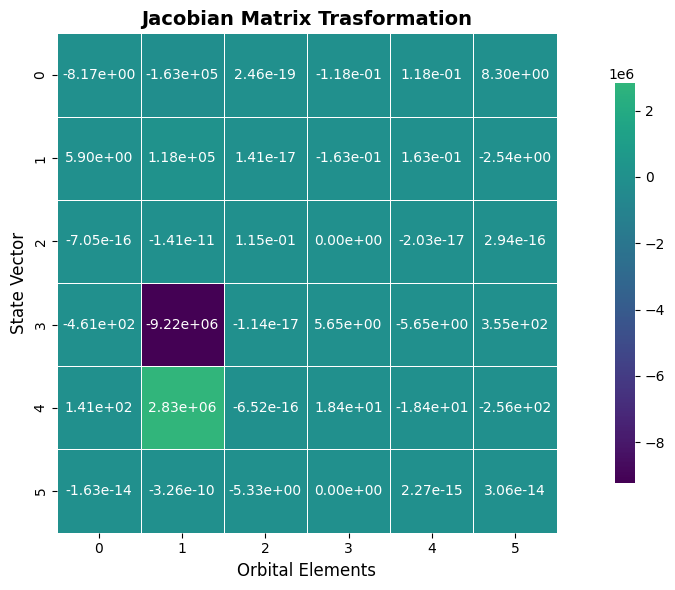

In [8]:
plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(jacobian, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Trasformation', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
jacobian_inv, _ = JaccobianComponents.Jacobian_inv(elements, grav_params)
jacobian_inv

array([[ 1.78585707e+04, -5.67696924e+03,  7.46624486e+03,
        -3.37684788e+02,  1.67424815e+02,  2.33327742e+02],
       [-8.93008373e-01,  2.83906136e-01, -3.73351134e-01,
         1.68861078e-02, -8.37181313e-03, -1.16672229e-02],
       [ 3.16096735e-17,  1.81091698e-15,  1.47895119e+01,
         2.81974409e-19,  1.61543030e-17,  1.31929988e-01],
       [ 7.41679085e-02,  4.24907663e+00,  3.47016290e+16,
         1.60290286e-03,  9.18302432e-02,  7.49965064e+14],
       [-2.12605965e-01, -1.16014123e+00,  3.47016290e+16,
        -8.61439935e-02,  1.47541788e-02,  7.49965064e+14],
       [-2.03508253e+00,  1.39888136e+00, -9.80058798e-01,
         4.91423496e-02, -1.56851970e-02, -2.11808460e-02]])

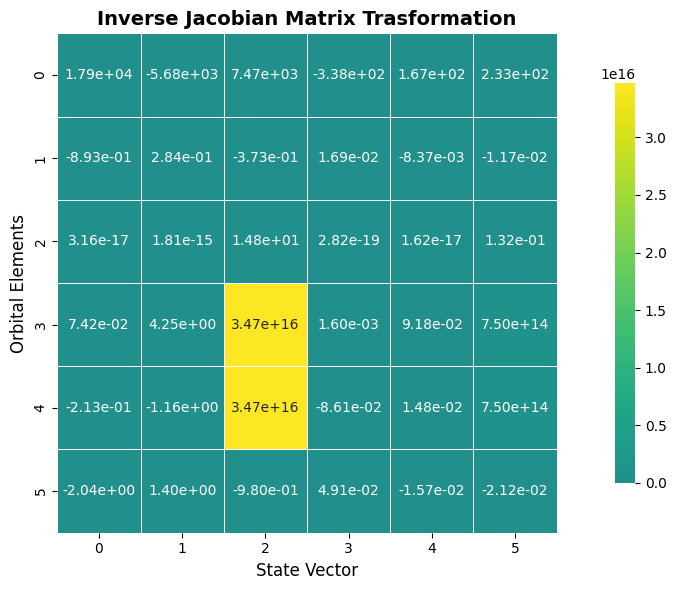

In [10]:
plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(jacobian_inv, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Inverse Jacobian Matrix Trasformation', fontsize=14, fontweight='bold')
plt.xlabel('State Vector', fontsize=12)
plt.ylabel('Orbital Elements', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
det = np.linalg.det(jacobian_inv)
det

470062612200.6214

In [12]:
OrbitTrasformations.Matrix_trasformation(i, w, Omega)


array([[ 1.00000000e+00,  0.00000000e+00, -2.13730337e-18],
       [ 0.00000000e+00, -1.00000000e+00, -1.22446028e-16],
       [-2.13730337e-18,  1.22446028e-16, -1.00000000e+00]])

In [13]:
position = OrbitTrasformations.state_vector(elements, grav_params)[:3]
velocity = OrbitTrasformations.state_vector(elements, grav_params)[3:]

position, velocity

(array([-1.63360481e-01,  1.18010318e-01, -1.41007437e-17]),
 array([ 1.84451936e+01, -5.65047650e+00,  6.52455429e-16]))

In [14]:
q = a*(1-e)
elements_spice = np.array([q, e, i, Omega, w, M, 0.0, mu])
et = 0 
state_vector_spice = spy.conics(elements_spice, et)
print('state vector using spice: ', state_vector_spice)

state vector using spice:  [-1.63360481e-01  1.18010318e-01 -1.41007437e-17  1.84451936e+01
 -5.65047650e+00  6.52455429e-16]


In [15]:
(mu)**0.5 * np.array([-3.78e-6, -1.15e-6, 0])

array([-2.37536059e-05, -7.22662614e-06,  0.00000000e+00])

In [16]:
JaccobianComponents.partial_a(elements, grav_params)

array([-8.16802404e-02,  5.90051588e-02, -7.05037187e-18, -4.61129840e+00,
        1.41261912e+00, -1.63113857e-16])

In [17]:
JaccobianComponents.partial_i(elements, grav_params)

array([ 2.46091911e-19,  1.40985961e-17,  1.15141311e-01, -1.13869173e-17,
       -6.52356057e-16, -5.32770289e+00])

In [18]:
JaccobianComponents.partial_Omega(elements, grav_params)

array([-0.11801032, -0.16336048,  0.        ,  5.6504765 , 18.4451936 ,
        0.        ])

In [19]:
JaccobianComponents.partial_w(elements, grav_params)

array([ 1.18010318e-01,  1.63360481e-01, -2.02550658e-17, -5.65047650e+00,
       -1.84451936e+01,  2.27061747e-15])

In [20]:
JaccobianComponents.partial_M(elements, grav_params)

array([ 8.30214786e+00, -2.54326912e+00,  2.93668994e-16,  3.54756879e+02,
       -2.56273560e+02,  3.06214565e-14])

### Test using professor example

In [21]:
mu=1
E = np.array([1.32894739, 0.82099007, 1.57079633, 0.78539816, 5.83284997, 0.07211871])
X = spy.conics(list(E)+[0, mu], 0)
X

array([ 1.        ,  0.99999999,  1.        , -0.1       , -0.1       ,
        1.        ])

In [22]:
#lets evaluate the parameters in the superior limit
q = E[0]
e = E[1]
i = E[2]
Omega = E[3]
w = E[4]
M = E[5]
a=q/(1-e)

elements = OrbitalElements(a=a, e=e, i=i, Omega=Omega, w=w, M=M)
grav_params = GravitationalParameters(mu=mu)

jacobian, _ = JaccobianComponents.Jacobian(elements, grav_params)
jacobian

array([[ 7.52475238e-01,  1.67704039e+02,  1.17690651e+00,
        -2.08648030e-01, -1.17690652e+00, -1.80451541e+01],
       [ 7.52475230e-01,  1.67704037e+02, -1.17690652e+00,
        -4.31564706e-01, -1.17690651e+00,  8.72426751e+00],
       [ 7.52475234e-01,  1.81356869e+02,  4.52698766e-01,
         0.00000000e+00, -1.57625895e-01,  3.94989152e+00],
       [ 3.76237618e-02,  6.27379609e+00,  1.38077899e-01,
        -4.31303493e-01, -1.38077899e-01,  1.68000293e+00],
       [ 3.76237633e-02,  6.27379644e+00, -1.38077900e-01,
        -8.92102172e-01, -1.38077896e-01, -8.12228841e-01],
       [-3.76237618e-01, -8.64556231e+01,  9.35789119e-01,
         0.00000000e+00, -3.25833874e-01, -6.47919549e+00]])

In [23]:
mu=1
celements = np.array([1.3, 0.5, np.pi/2, np.pi, np.pi, np.pi])
#celements = np.array([1.32894739, 0.82099007, 1.57079633, 0.78539816, 5.83284997, 0.07211871])
state = spy.conics(list(celements)+[0, mu], 0)

q,e,i,W,w,M=celements
a=q/(1-e)

#Orbit signature
if e<1:
    s=+1
elif e>1:
    s=-1
else:
    s=0

#Trigonometric function
cosi,sini=np.cos(i), np.sin(i)
cosw,sinw=np.cos(w), np.sin(w)
cosW,sinW=np.cos(W), np.sin(W)

#Components of the rotation matrix
A=(cosW*cosw-cosi*sinW*sinw);B=(-cosW*sinw-cosw*cosi*sinW)
C=(cosw*sinW+sinw*cosi*cosW);D=(-sinw*sinW+cosw*cosi*cosW)
F=sinw*sini;G=cosw*sini

#Primary auxiliar variables
ab=np.abs(a)
n=np.sqrt(mu/ab**3)
nu=n*a**2
eps=np.sqrt(s*(1-e**2))

#Get cartesian coordinates
x,y,z,vx,vy,vz=state
r=(x**2+y**2+z**2)**0.5
nur=nu/r

#Eccentric anomaly as obtained from indirect information
#From the radial equation: r = a (1-e cos E)
cosE=(1/e)*(1-r/a)

#From the general equation for y
sinE=(y-a*(cosE-e)*C)/(ab*eps*D)

#dX/da
Ja=np.array([x/a,y/a,z/a,-vx/(2*a),-vy/(2*a),-vz/(2*a)])

#dX/de
dcosEde=-s*a*sinE**2/r
dsinEde=a*cosE*sinE/r
dnurde=(nu*a/r**2)*(cosE-(ab/r)*e*sinE**2)
depsde=-s*e/eps

drAde=a*(dcosEde-1)
drBde=ab*(depsde*sinE+eps*dsinEde)

dvAde=-(dnurde*sinE+nur*dsinEde)
dvBde=(dnurde*eps*cosE+nur*depsde*cosE+nur*eps*dcosEde)

Je=np.array([
    drAde*A+drBde*B,
    drAde*C+drBde*D,
    drAde*F+drBde*G,
    dvAde*A+dvBde*B,
    dvAde*C+dvBde*D,
    dvAde*F+dvBde*G,
])

#dX/di
Ji=np.array([z*sinW,-z*cosW,-x*sinW+y*cosW,vz*sinW,-vz*cosW,-vx*sinW+vy*cosW])

#dX/dw
Jw=np.array([-y*cosi-z*sini*cosW,x*cosi-z*sini*sinW,sini*(x*cosW+y*sinW),
                -vy*cosi-vz*sini*cosW,vx*cosi-vz*sini*sinW,sini*(vx*cosW+vy*sinW)])

#dX/dW
JW=np.array([-y,x,0,-vy,vx,0])

#dX/dM
JM=np.concatenate(((ab**3/mu)**0.5*np.array([vx,vy,vz]),
                    (mu*ab**3)**0.5*np.array([-x/r**3,-y/r**3,-z/r**3])))

In [24]:
Ji

array([-5.84906315e-32, -4.77612252e-16,  0.00000000e+00,  4.38493894e-17,
        3.58057437e-01,  2.19246947e-17])

In [25]:
q = celements[0]
e = celements[1]
i = celements[2]
Omega = celements[3]
w = celements[4]
M = celements[5]
a=q/(1-e)
elements = OrbitalElements(a, e, i, Omega, w, M=M)
grav_params = GravitationalParameters(mu=mu)
JaccobianComponents.partial_i(elements, grav_params)

array([-5.84906315e-32, -4.77612252e-16,  0.00000000e+00,  4.38493894e-17,
        3.58057437e-01,  2.19246947e-17])

### Testing jacobians 

In [26]:
mu = G_cu
q = 1.3
e = 0.5
i = np.pi/2
Omega = np.pi
w = np.pi
M = np.pi
a=q/(1-e)

E = [q, e, i, Omega, w, M]
X = spy.conics(E+[0, mu], 0)
print('Elements:', E)
print('State Vector:', X)

Elements: [1.3, 0.5, 1.5707963267948966, 3.141592653589793, 3.141592653589793, 3.141592653589793]
State Vector: [-3.90000000e+00  4.77612252e-16 -3.47526914e-15 -5.93728940e-16
 -1.37775280e-16  2.25004107e+00]


In [27]:
#calculo del jaccboniano propio

elements = OrbitalElements(a=a, e=e, i=i, Omega=Omega, w=w, M=M)
grav_params = GravitationalParameters(mu=mu)

JXoE_ownq, JXoE_own = JaccobianComponents.Jacobian(elements, grav_params)
JEoX_ownq = np.linalg.inv(JXoE_ownq)
JEoX_own = np.linalg.inv(JXoE_own)
#calculo del jaccboniano codigo jorge
JXoE_jorgeq, JXoE_jorge = calcKeplerianJacobians(mu,E,X)
JEoX_jorgeq = np.linalg.inv(JXoE_jorgeq)
JEoX_jorge = np.linalg.inv(JXoE_jorge)

#calculo del jacobiano numerico
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JEoX_num=computeNumericalJacobian(X2E,X,dX,**args)
JXoE_num = np.linalg.inv(JEoX_num)

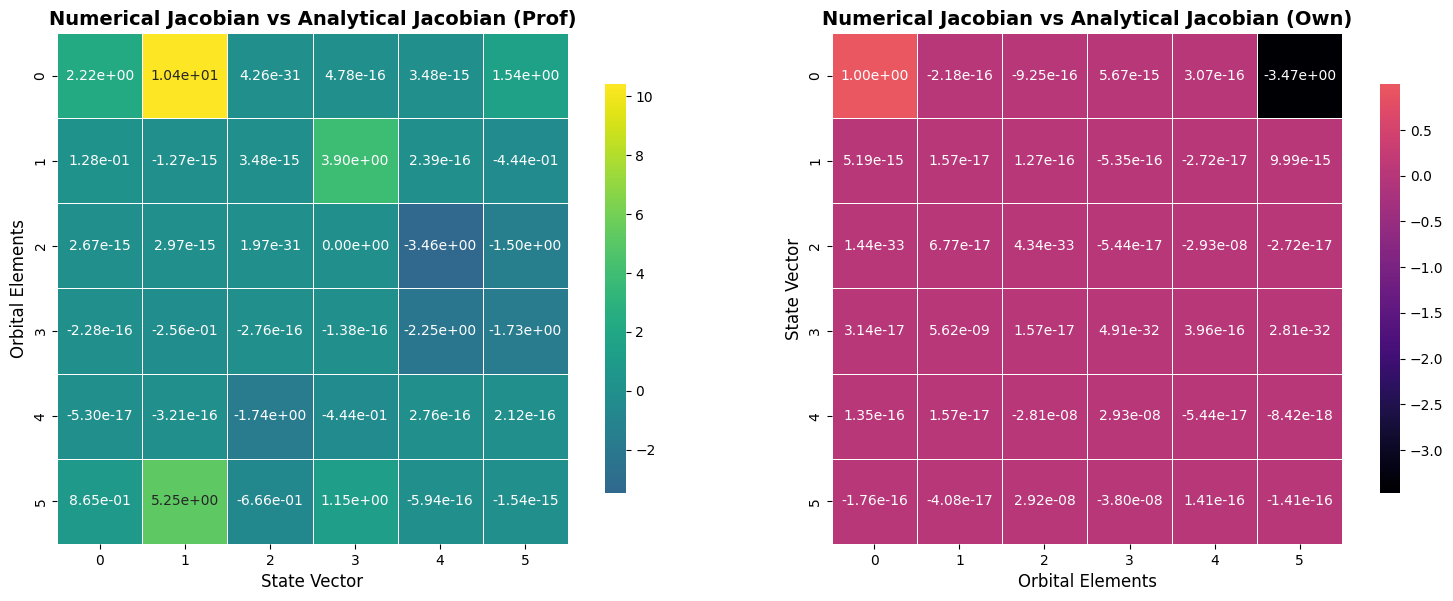

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(JEoX_num - JXoE_jorgeq, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8},
            ax=axes[0])
axes[0].set_title('Numerical Jacobian vs Analytical Jacobian (Prof)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('State Vector', fontsize=12)
axes[0].set_ylabel('Orbital Elements', fontsize=12)

# Second heatmap (example: use JXoE_jorge or any other matrix you want to compare)
sns.heatmap(JEoX_num - JEoX_ownq, 
            annot=True, 
            fmt='.2e', 
            cmap='magma', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8},
            ax=axes[1])
axes[1].set_title('Numerical Jacobian vs Analytical Jacobian (Own)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Orbital Elements', fontsize=12)
axes[1].set_ylabel('State Vector', fontsize=12)

plt.tight_layout()
plt.show()

In [29]:
print('determinates: ', np.linalg.det(JEoX_num), np.linalg.det(JEoX_jorgeq), np.linalg.det(JEoX_ownq))

determinates:  0.004998387282702396 0.0049983893178970834 0.004998389317897079


In [34]:
mu = G_cu
q = 1
e = 0.8
i = np.pi/3
Omega = np.pi/2
w = np.pi/2
M = np.pi/2
a=q/(1-e)

E = [q, e, i, Omega, w, M]
X = spy.conics(E+[0, mu], 0)
print('Elements:', E)
print('State Vector:', X)

Elements: [1, 0.8, 1.0471975511965976, 1.5707963267948966, 1.5707963267948966, 1.5707963267948966]
State Vector: [ 3.49526215 -2.40425356 -6.05397163  0.76166705  0.6821262  -1.31924602]


In [35]:
#calculo del jaccboniano propio

elements = OrbitalElements(a=a, e=e, i=i, Omega=Omega, w=w, M=M)
grav_params = GravitationalParameters(mu=mu)

JXoE_own, _ = JaccobianComponents.Jacobian(elements, grav_params)
JEoX_own = np.linalg.inv(JXoE_own)

#calculo del jaccboniano codigo jorge
JXoE_jorge, _ = calcKeplerianJacobians(mu,E,X)
JEoX_jorge = np.linalg.inv(JXoE_jorge)

#calculo del jacobiano numerico
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JEoX_num=computeNumericalJacobian(X2E,X,dX,**args)
JXoE_num = np.linalg.inv(JEoX_num)

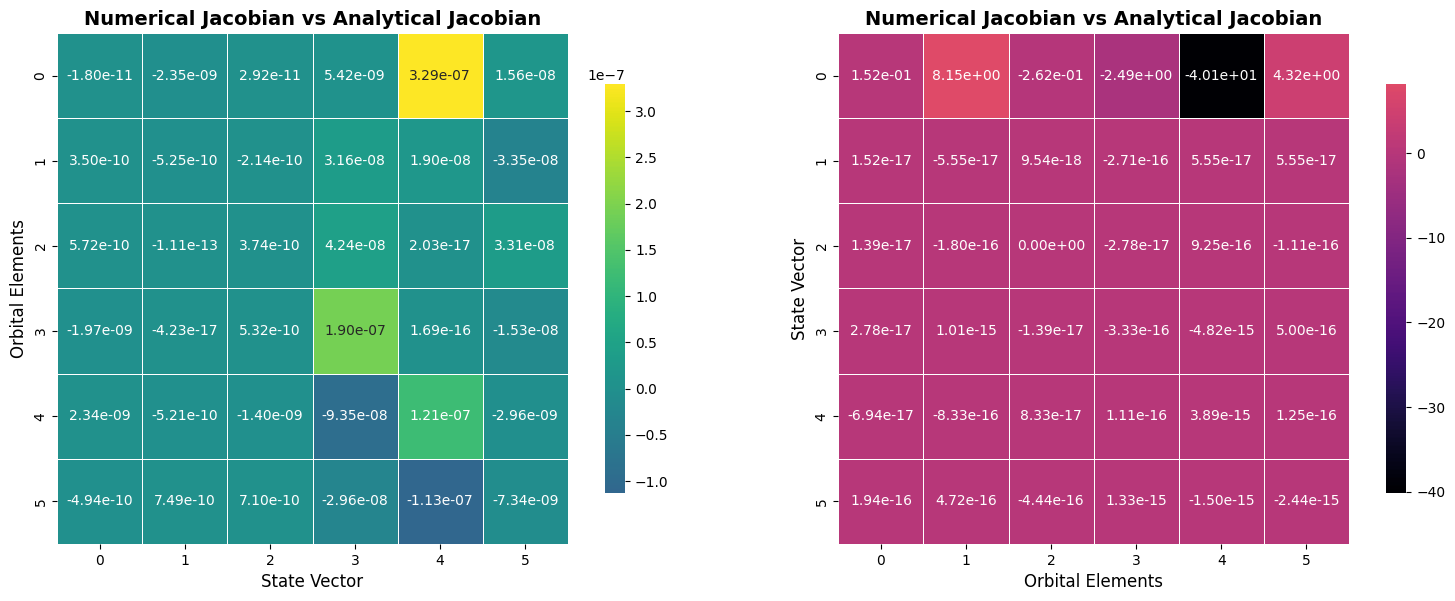

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(JEoX_num - JEoX_jorge, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8},
            ax=axes[0])
axes[0].set_title('Numerical Jacobian vs Analytical Jacobian', fontsize=14, fontweight='bold')
axes[0].set_xlabel('State Vector', fontsize=12)
axes[0].set_ylabel('Orbital Elements', fontsize=12)

# Second heatmap (example: use JXoE_jorge or any other matrix you want to compare)
sns.heatmap(JEoX_jorge - JEoX_own, 
            annot=True, 
            fmt='.2e', 
            cmap='magma', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8},
            ax=axes[1])
axes[1].set_title('Numerical Jacobian vs Analytical Jacobian', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Orbital Elements', fontsize=12)
axes[1].set_ylabel('State Vector', fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
print('determinates: ', np.linalg.det(JEoX_num), np.linalg.det(JEoX_jorge), np.linalg.det(JEoX_own))

determinates:  0.0010404972676838424 0.0010404977095161071 0.0010404977095161128
